In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/silent-speech-emg/Silent Speech EMG/Silent speech/emg_wasem.txt
/kaggle/input/silent-speech-emg/Silent Speech EMG/Silent speech/emg_nikita_butiaev.txt
/kaggle/input/silent-speech-emg/Silent Speech EMG/Silent speech/emg_glazyrin_semion.txt
/kaggle/input/silent-speech-emg/Silent Speech EMG/Silent speech/emg_saudi.txt
/kaggle/input/silent-speech-emg/Silent Speech EMG/Voice speech/emg_wasem.txt
/kaggle/input/silent-speech-emg/Silent Speech EMG/Voice speech/emg_nikita_butiaev.txt
/kaggle/input/silent-speech-emg/Silent Speech EMG/Voice speech/emg_glazyrin_semion.txt
/kaggle/input/silent-speech-emg/Silent Speech EMG/Voice speech/emg_saudi.txt


In [2]:
!pip install noisereduce

  Obtaining dependency information for noisereduce from https://files.pythonhosted.org/packages/ba/87/4d76a0c394343c09213e098823715639386dcabec55234cae28697f3ce65/noisereduce-3.0.0-py3-none-any.whl.metadata


In [3]:
import os
import pandas as pd
import numpy as np
import noisereduce as nr

import matplotlib.pyplot as plt

In [4]:
def print_multiple_data(directory_path):
    try:
        # list all files in the directory
        files = os.listdir(directory_path)
        
        # filter out the CSV files
        csv_files = [f for f in files if f.endswith('.csv') or f.endswith('.txt')]
        
        # read and print each CSV file
        for file in csv_files:
            data = pd.read_csv(os.path.join(directory_path, file), delimiter = "\t")
            print(f"Data from {file}:\n", data, "\n")
            
    except FileNotFoundError:
        print("Directory Not Found")
    except Exception as e:
        print(str(e))

# call the function
directory_path = '/kaggle/input/silent-speech-emg/Silent Speech EMG/Silent speech/' # replace with your directory path
print_multiple_data(directory_path)

Data from emg_wasem.txt:
       1.4231505393981934,650.0
0      1.595064640045166,650.0
1      1.657557725906372,650.0
2      1.720057487487793,650.0
3     1.7669446468353271,651.0
4     1.8294470310211182,650.0
...                        ...
4317    239.71439695358276,0.0
4318    239.77689862251282,0.0
4319    239.82375645637512,0.0
4320     239.8862714767456,0.0
4321    239.93314456939697,0.0

[4322 rows x 1 columns] 

Data from emg_nikita_butiaev.txt:
       1.4009244441986084,195.0
0     1.5728044509887695,289.0
1      1.635324239730835,201.0
2     1.6821486949920654,300.0
3     1.7290723323822021,198.0
4     1.7915687561035156,319.0
...                        ...
2212  119.74591088294983,329.0
2213  119.79277443885803,329.0
2214  119.85527467727661,282.0
2215   119.9177873134613,368.0
2216  119.96464467048645,104.0

[2217 rows x 1 columns] 

Data from emg_glazyrin_semion.txt:
       1.4476776123046875,639.0
0      1.603942632675171,117.0
1     1.6664376258850098,596.0
2     1.7289

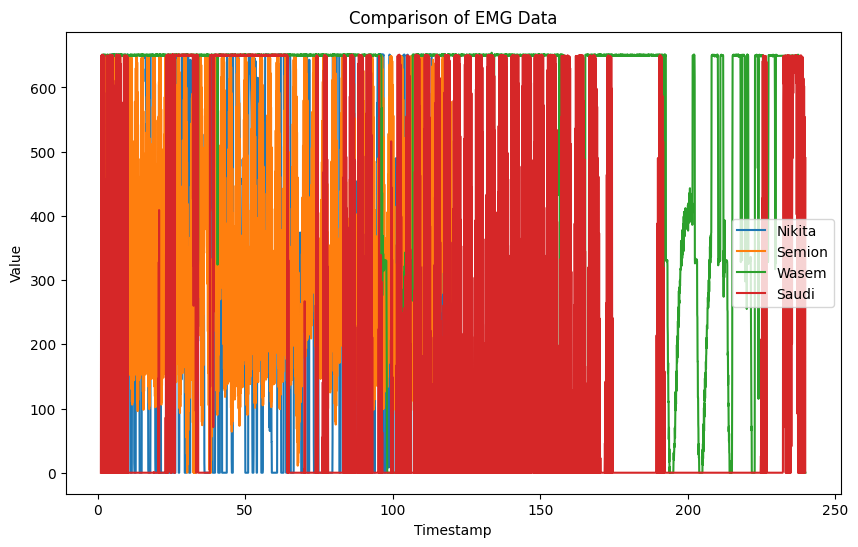

In [5]:
# Load the data
data_nikita = pd.read_csv('/kaggle/input/silent-speech-emg/Silent Speech EMG/Silent speech/emg_nikita_butiaev.txt', names=['timestamp', 'value'])
data_semion = pd.read_csv('/kaggle/input/silent-speech-emg/Silent Speech EMG/Silent speech/emg_glazyrin_semion.txt', names=['timestamp', 'value'])
data_wasem = pd.read_csv('/kaggle/input/silent-speech-emg/Silent Speech EMG/Silent speech/emg_wasem.txt', names=['timestamp', 'value'])
data_saudi = pd.read_csv('/kaggle/input/silent-speech-emg/Silent Speech EMG/Silent speech/emg_saudi.txt', names=['timestamp', 'value'])

# Plot the data
plt.figure(figsize=(10, 6))

plt.plot(data_nikita['timestamp'], data_nikita['value'], label='Nikita')
plt.plot(data_semion['timestamp'], data_semion['value'], label='Semion')
plt.plot(data_wasem['timestamp'], data_wasem['value'], label='Wasem')
plt.plot(data_saudi['timestamp'], data_saudi['value'], label='Saudi')

plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.title('Comparison of EMG Data')
plt.legend()

plt.show()

In [6]:
# Define a simple moving average function
def moving_average(data, window_size):
    return data.rolling(window=window_size).mean()

# Apply the moving average filter
window_size = 5  # Adjust this value based on your data
data_nikita['value_filtered'] = moving_average(data_nikita['value'], window_size)
data_semion['value_filtered'] = moving_average(data_semion['value'], window_size)
data_wasem['value_filtered'] = moving_average(data_wasem['value'], window_size)
data_saudi['value_filtered'] = moving_average(data_saudi['value'], window_size)

# Print the output
print("Nikita's Data:\n", data_nikita.head())
print("\nSemion's Data:\n", data_semion.head())
print("\nWasem's Data:\n", data_wasem.head())
print("\nSaudi's Data:\n", data_saudi.head())

Nikita's Data:
    timestamp  value  value_filtered
0   1.400924  195.0             NaN
1   1.572804  289.0             NaN
2   1.635324  201.0             NaN
3   1.682149  300.0             NaN
4   1.729072  198.0           236.6

Semion's Data:
    timestamp  value  value_filtered
0   1.447678  639.0             NaN
1   1.603943  117.0             NaN
2   1.666438  596.0             NaN
3   1.728937  104.0             NaN
4   1.775830  538.0           398.8

Wasem's Data:
    timestamp  value  value_filtered
0   1.423151  650.0             NaN
1   1.595065  650.0             NaN
2   1.657558  650.0             NaN
3   1.720057  650.0             NaN
4   1.766945  651.0           650.2

Saudi's Data:
    timestamp  value  value_filtered
0   1.080270    0.0             NaN
1   1.236545  649.0             NaN
2   1.299017    0.0             NaN
3   1.361536  650.0             NaN
4   1.408395    0.0           259.8


In [7]:
# Reduce noise from the data
data_nikita['value_filtered'] = nr.reduce_noise(y=data_nikita['value'].to_numpy(), sr=44100)
data_semion['value_filtered'] = nr.reduce_noise(y=data_semion['value'].to_numpy(), sr=44100)
data_wasem['value_filtered'] = nr.reduce_noise(y=data_wasem['value'].to_numpy(), sr=44100)
data_saudi['value_filtered'] = nr.reduce_noise(y=data_saudi['value'].to_numpy(), sr=44100)

# Print the output
print("Nikita's Data:\n", data_nikita.head())
print("\nSemion's Data:\n", data_semion.head())
print("\nWasem's Data:\n", data_wasem.head())
print("\nSaudi's Data:\n", data_saudi.head())

Nikita's Data:
    timestamp  value  value_filtered
0   1.400924  195.0       85.002382
1   1.572804  289.0      146.380686
2   1.635324  201.0       88.685510
3   1.682149  300.0      153.180705
4   1.729072  198.0       86.918777

Semion's Data:
    timestamp  value  value_filtered
0   1.447678  639.0      380.997964
1   1.603943  117.0       34.390656
2   1.666438  596.0      353.410680
3   1.728937  104.0       25.402737
4   1.775830  538.0      315.199751

Wasem's Data:
    timestamp  value  value_filtered
0   1.423151  650.0      293.475155
1   1.595065  650.0      295.435239
2   1.657558  650.0      290.642714
3   1.720057  650.0      291.779562
4   1.766945  651.0      284.312556

Saudi's Data:
    timestamp  value  value_filtered
0   1.080270    0.0      -26.196853
1   1.236545  649.0      396.455647
2   1.299017    0.0      -26.137941
3   1.361536  650.0      397.349000
4   1.408395    0.0      -26.533805


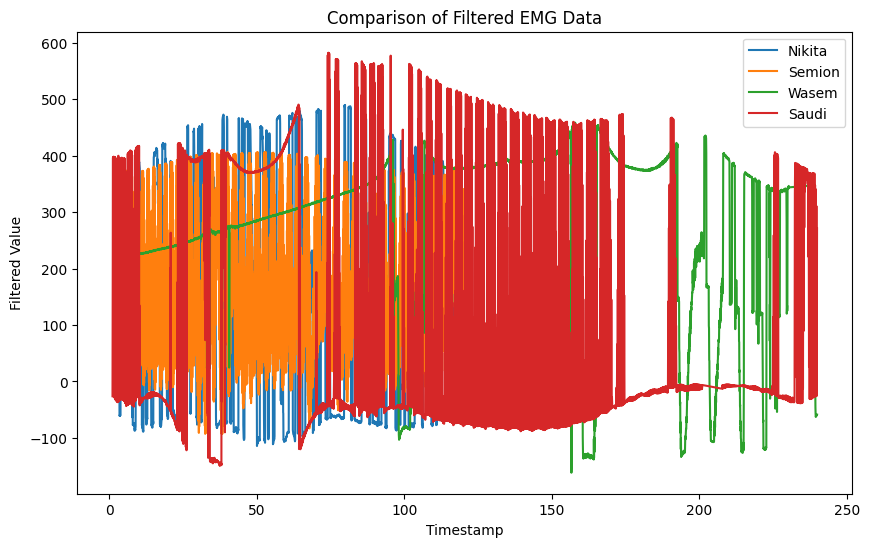

In [8]:
# Plot the filtered data
plt.figure(figsize=(10, 6))

plt.plot(data_nikita['timestamp'], data_nikita['value_filtered'], label='Nikita')
plt.plot(data_semion['timestamp'], data_semion['value_filtered'], label='Semion')
plt.plot(data_wasem['timestamp'], data_wasem['value_filtered'], label='Wasem')
plt.plot(data_saudi['timestamp'], data_saudi['value_filtered'], label='Saudi')

plt.xlabel('Timestamp')
plt.ylabel('Filtered Value')
plt.title('Comparison of Filtered EMG Data')
plt.legend()

plt.show()


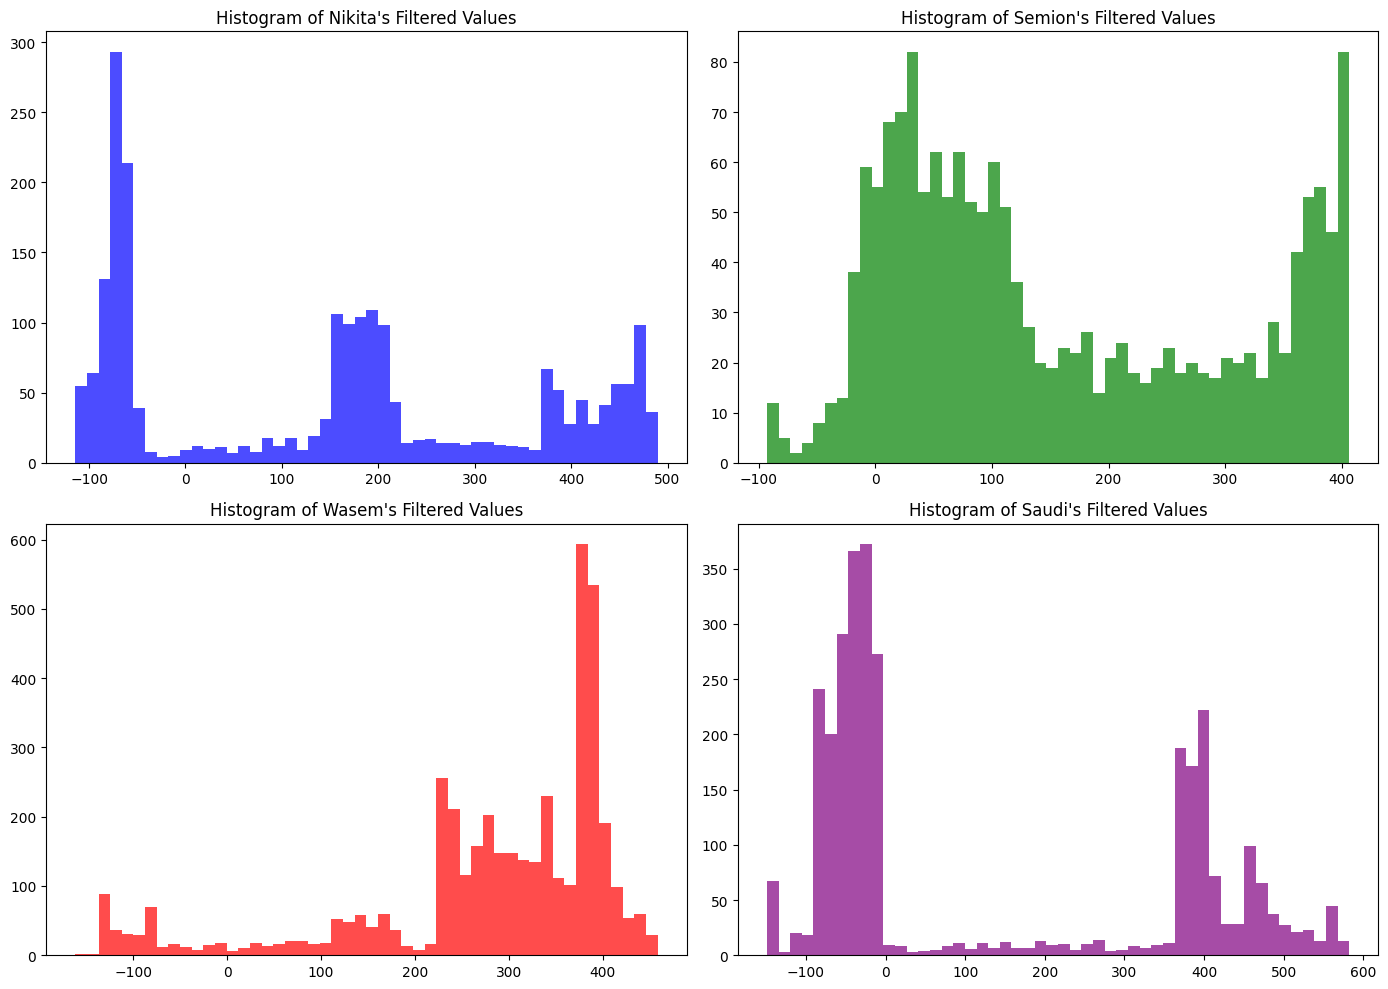

In [9]:
# Plotting histograms
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.hist(data_nikita['value_filtered'], bins=50, color='blue', alpha=0.7)
plt.title('Histogram of Nikita\'s Filtered Values')

plt.subplot(2, 2, 2)
plt.hist(data_semion['value_filtered'], bins=50, color='green', alpha=0.7)
plt.title('Histogram of Semion\'s Filtered Values')

plt.subplot(2, 2, 3)
plt.hist(data_wasem['value_filtered'], bins=50, color='red', alpha=0.7)
plt.title('Histogram of Wasem\'s Filtered Values')

plt.subplot(2, 2, 4)
plt.hist(data_saudi['value_filtered'], bins=50, color='purple', alpha=0.7)
plt.title('Histogram of Saudi\'s Filtered Values')

plt.tight_layout()
plt.show()

In [10]:
# Import necessary library
import pandas as pd

# Concatenate the datasets
data_all = pd.concat([data_nikita, data_semion, data_wasem, data_saudi])

# Print the combined dataset
print(data_all)

       timestamp  value  value_filtered
0       1.400924  195.0       85.002382
1       1.572804  289.0      146.380686
2       1.635324  201.0       88.685510
3       1.682149  300.0      153.180705
4       1.729072  198.0       86.918777
...          ...    ...             ...
3101  239.478687  602.0      340.498120
3102  239.588054    0.0      -25.954652
3103  239.713045  554.0      310.696705
3104  239.822430    0.0      -25.709426
3105  239.931805  490.0      271.022133

[11308 rows x 3 columns]


In [11]:
# Save the combined dataset to a csv file
data_all.to_csv('/kaggle/working/combined_data.csv', index=False)

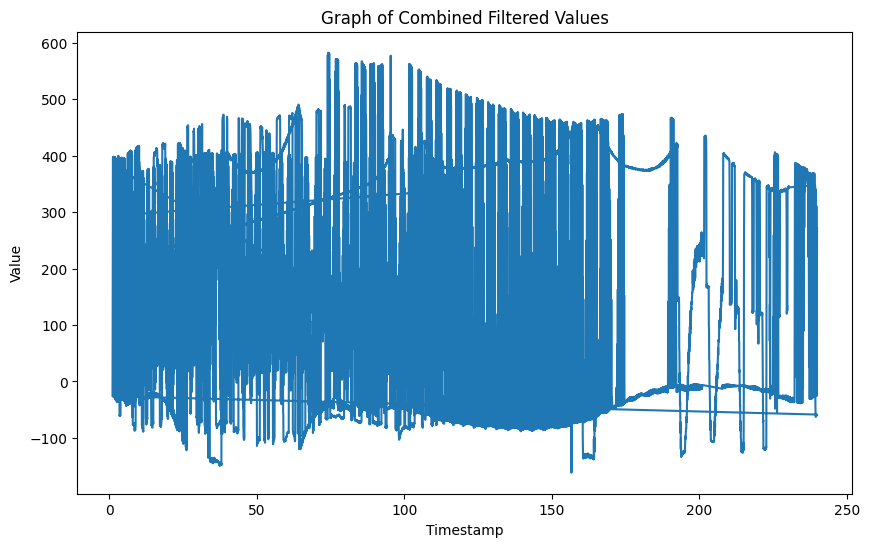

In [12]:
# Plot the combined dataset
plt.figure(figsize=(10, 6))
plt.plot(data_all['timestamp'], data_all['value_filtered'])
plt.title('Graph of Combined Filtered Values')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.show()

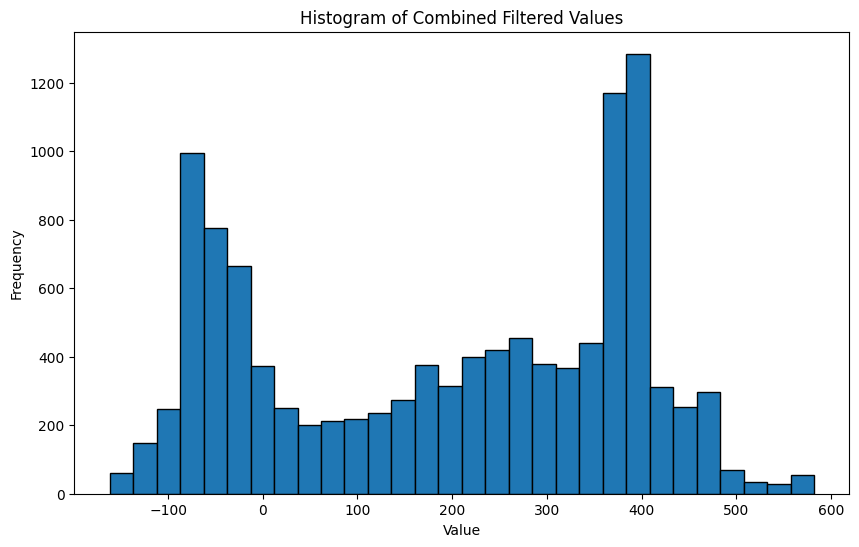

In [13]:
# Plot the combined dataset as a histogram
plt.figure(figsize=(10, 6))
plt.hist(data_all['value_filtered'], bins=30, edgecolor='black')
plt.title('Histogram of Combined Filtered Values')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [14]:
# Load the data from the CSV file
df = pd.read_csv('/kaggle/working/combined_data.csv')

# Calculate the total recording duration
total_duration = df['timestamp'].max() - df['timestamp'].min()

print(f"The total recording duration is {total_duration} units.")

The total recording duration is 238.85287499427795 units.


In [15]:
# Import necessary libraries
import pandas as pd

# Load the data from the CSV file
df = pd.read_csv('/kaggle/working/combined_data.csv')

# Remove rows with missing values
df = df.dropna()

# Remove rows where 'value' is less than 0
df = df[df['value'] >= 0]

# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows where 'value' is not a number
df = df[pd.to_numeric(df['value'], errors='coerce').notnull()]

# Save the cleaned data to a new CSV file
df.to_csv('/kaggle/working//cleaned_data.csv', index=False)

print("Data cleaning completed. The cleaned data is saved as 'cleaned_data.csv'.")

Data cleaning completed. The cleaned data is saved as 'cleaned_data.csv'.


In [16]:
# Import necessary libraries
import pandas as pd

# Load the cleaned data from the CSV file
df_cleaned = pd.read_csv('/kaggle/working/cleaned_data.csv')

# Print the first 5 rows of the cleaned data
print(df_cleaned.head())

   timestamp  value  value_filtered
0   1.400924  195.0       85.002382
1   1.572804  289.0      146.380686
2   1.635324  201.0       88.685510
3   1.682149  300.0      153.180705
4   1.729072  198.0       86.918777


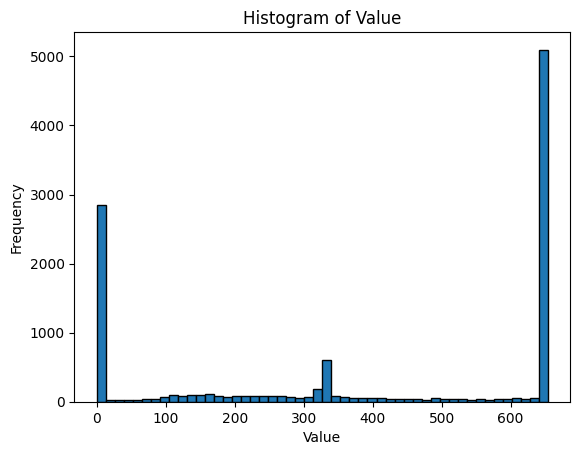

In [17]:
# Plot a histogram of the 'value' column
plt.hist(df_cleaned['value'], bins=50, edgecolor='black')

# Add title and labels
plt.title('Histogram of Value')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Show the plot
plt.show()